In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from tqdm import tqdm
from scipy.signal import savgol_filter
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})

# EH Self Acceleration In Sine Electric Field

In [ ]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)
Ve, Xe = np.meshgrid(ve, x)
Vi, Xi = np.meshgrid(vi, x)

dt = 0.05
max_steps = 30000
data_steps = int(max_steps / 1)
data_num = int(max_steps / data_steps) + 1

# path1 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-015" # verfied
# path2 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-0125" # verfied
# path1 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-0075" # verfied
# path2 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-005"  # verfied

# path1 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue004"  # verfied
# path2 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue-004" # verfied
path1 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue002"  # verfied
path2 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue-002" # verfied

print(data_num)
print("real time = ", max_steps * dt)

2
real time =  1500.0


In [15]:
phi1 = np.loadtxt(os.path.join(path1, "Phi_evolution"))
phi2 = np.loadtxt(os.path.join(path2, "Phi_evolution"))
t = np.linspace(0, max_steps, num = max_steps + 1, endpoint=True) * dt

In [16]:
progesses = np.arange(0,data_num,1)

fi1 = []
fi2 = []

for progess in tqdm(progesses):
    fi1_temp = np.loadtxt(os.path.join(path1,"fi"+str(progess)))
    fi1.append(fi1_temp)

    fi2_temp = np.loadtxt(os.path.join(path2,"fi"+str(progess)))
    fi2.append(fi2_temp)

100%|██████████| 2/2 [00:02<00:00,  1.37s/it]


In [17]:
ui = 0.1
Ti = 5
mi = 1836
vti = np.sqrt(Ti/mi)
test_frame = data_num - 1

In [18]:
phi1_final = phi1[:,-1]
phi2_final = phi2[:,-1]

x_peak1_idx = np.argmax(phi1_final)
x_peak1 = x_peak1_idx * dx

x_peak2_idx = np.argmax(phi2_final)
x_peak2 = x_peak2_idx * dx

In [19]:
def phi2_fit1(x, psi_fit, delta_fit):
    xp = (x - x_peak1) / delta_fit
    return psi_fit * np.cosh(xp) ** (-2)


def phi2_fit2(x, psi_fit, delta_fit):
    xp = (x - x_peak2) / delta_fit
    return psi_fit * np.cosh(xp) ** (-2)


fit_offset = 300

x_fit1_scale = x[x_peak1_idx - fit_offset : x_peak1_idx + fit_offset]
phi_fit1 = phi1_final[x_peak1_idx - fit_offset : x_peak1_idx + fit_offset]
[psi_fit1, Delta_fit1], pcov = curve_fit(phi2_fit1, x_fit1_scale, phi_fit1)

x_fit2_scale = x[x_peak2_idx - fit_offset : x_peak2_idx + fit_offset]
phi_fit2 = phi2_final[x_peak2_idx - fit_offset : x_peak2_idx + fit_offset]
[psi_fit2, Delta_fit2], pcov = curve_fit(phi2_fit2, x_fit2_scale, phi_fit2)

vi_r1 = np.sqrt(2 * psi_fit1 / mi)
print("x_peak1 = ", x_peak1)
print("psi_fit1 = ", psi_fit1)
print("vi_r1 = ", vi_r1)

vi_r2 = np.sqrt(2 * psi_fit2 / mi)
print("x_peak2 = ", x_peak2)
print("psi_fit2 = ", psi_fit2)
print("vi_r2 = ", vi_r2)

x_peak1 =  90.40622219932817
psi_fit1 =  0.02441835121706292
vi_r1 =  0.005157471389130353
x_peak2 =  90.26481517816134
psi_fit2 =  0.033353833438276574
vi_r2 =  0.00602769872285829


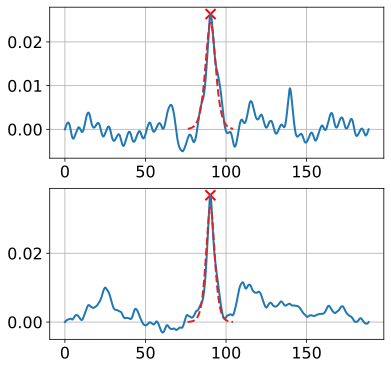

In [20]:
fig, (ax1, ax2) = plt.subplots(figsize=(6, 6), ncols=1, nrows=2)
ax1.plot(x, phi1_final, linestyle='-', color='tab:blue',label=r'$\tilde{E}_0=0.1$')
ax1.scatter(x_peak1, phi1_final[x_peak1_idx], color='red', marker='x', s=100, label=r'$\psi_{peak}=$'+str(round(phi1_final[x_peak1_idx],3)))
ax1.plot(x_fit1_scale, phi2_fit1(x_fit1_scale, psi_fit1, Delta_fit1), "--", color="tab:red", label=r"$\mathrm{sech}^2$ fit")
ax1.grid()
ax2.plot(x, phi2_final, linestyle='-', color='tab:blue',label=r'$\tilde{E}_0=0.1$')
ax2.scatter(x_peak2, phi2_final[x_peak2_idx], color='red', marker='x', s=100, label=r'$\psi_{peak}=$'+str(round(phi2_final[x_peak2_idx],3)))
ax2.plot(x_fit2_scale, phi2_fit2(x_fit2_scale, psi_fit2, Delta_fit2), "--", color="tab:red", label=r"$\mathrm{sech}^2$ fit")
ax2.grid()
plt.show()

In [21]:
fi1_sim_smooth = savgol_filter(fi1[test_frame][0,:], window_length=80, polyorder=7)
fi2_sim_smooth = savgol_filter(fi2[test_frame][0,:], window_length=80, polyorder=7)

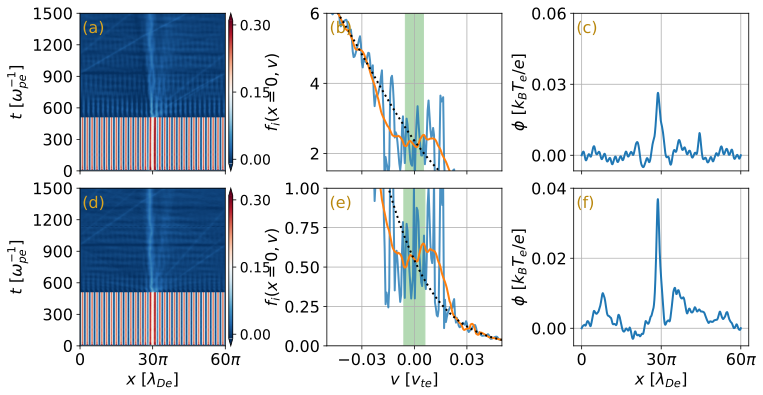

In [22]:
xi_ticks = [-0.03, 0.0, 0.03]
T, X = np.meshgrid(t, x)

fig, ([ax1, ax3, ax5], [ax2, ax4, ax6]) = plt.subplots(
    figsize=(12, 6), ncols=3, nrows=2
)

cb1 = ax1.pcolormesh(X, T, phi1, vmin=-0.01, vmax=0.31, cmap=cm.RdBu_r, rasterized=True)
ax1.set_ylabel(r"$t~[\omega_{pe}^{-1}]$")
ax1.set_xticks([0, 30*np.pi, 60*np.pi], [])
ax1.set_yticks([0, 300, 600, 900, 1200, 1500], [r"$0$", r"$300$", r"$600$", r"$900$", r"$1200$", r"$1500$"])

cb2 = ax2.pcolormesh(X, T, phi2, vmin=-0.01, vmax=0.31, cmap=cm.RdBu_r, rasterized=True)
ax2.set_xticks([0, 30*np.pi, 60*np.pi], ["0", r"$30\pi$", r"$60\pi$"])
ax2.set_yticks([0, 300, 600, 900, 1200, 1500], [r"$0$", r"$300$", r"$600$", r"$900$", r"$1200$", r"$1500$"])
ax2.set_xlabel(r"$x~[\lambda_{De}]$")
ax2.set_ylabel(r"$t~[\omega_{pe}^{-1}]$")

cbar1 = plt.colorbar(cb1, ticks=[0.0, 0.15, 0.3], extend="both",aspect=40, pad=0.02)
cbar1.ax.tick_params(labelsize=14)
cbar2 = plt.colorbar(cb2, ticks=[0.0, 0.15, 0.3], extend="both",aspect=40, pad=0.02)
cbar2.ax.tick_params(labelsize=14)

ax3.plot(
    vi, fi1[test_frame][0, :], linestyle="-", color="tab:blue", label="final", alpha=0.8
)
ax3.plot(vi, fi1_sim_smooth, linestyle="-", color="tab:orange", label="smoothed final")
ax3.plot(vi, fi1[0][0, :], linestyle=":", color="black", label="initial")
ax3.axvspan(-vi_r1, vi_r1, alpha=0.3, color="green")

ax3.set_xlim(-0.05, +0.05)
ax3.set_xticks(xi_ticks, [])
ax3.set_ylabel(r"$f_i(x=0, v)$")
# ax3.set_ylim(0, 1.0) #Ui015
# ax3.set_ylim(1, 4.0) #Ui0075
# ax3.set_ylim(0, 4.0) #Ue0025
# ax3.set_ylim(1.5, 6.0) #Ue004
ax3.set_ylim(1.5, 6.0) #Ue002
ax3.set_xticks(xi_ticks)
ax3.grid()

ax4.plot(
    vi, fi2[test_frame][0, :], linestyle="-", color="tab:blue", label="final", alpha=0.8
)
ax4.plot(vi, fi2_sim_smooth, linestyle="-", color="tab:orange", label="smoothed final")
ax4.plot(vi, fi2[0][0, :], linestyle=":", color="black", label="initial")
ax4.axvspan(-vi_r2, vi_r2, alpha=0.3, color="green")

ax4.set_xlim(-0.05, +0.05)
ax4.set_xlabel(r"$v ~[v_{te}]$")
ax4.set_ylabel(r"$f_i(x=0, v)$")
# ax4.set_ylim(0, 1.5) #Ui0125
# ax4.set_ylim(2.0, 6.5) #Ui005
# ax4.set_ylim(0, 1.0) #Ue-0025
# ax4.set_ylim(0, 1.0) #Ue-004
ax4.set_ylim(0, 1.0) #Ue-002
ax4.set_xticks(xi_ticks)
ax4.grid()

ax5.plot(x, phi1_final, linestyle="-", color="tab:blue")
ax5.set_xticks([0, 30 * np.pi, 60 * np.pi], [])
ax5.set_yticks([0, 0.03, 0.06])
ax5.set_ylabel(r"$\phi~[k_BT_{e}/e]$")
ax5.grid()

ax6.plot(x, phi2_final, linestyle="-", color="tab:blue")
ax6.set_xticks([0, 30 * np.pi, 60 * np.pi], ["0", r"$30\pi$", r"$60\pi$"])
ax6.set_yticks([0, 0.02, 0.04])
ax6.set_xlabel(r"$x~[\lambda_{De}]$")
ax6.set_ylabel(r"$\phi~[k_BT_{e}/e]$")
ax6.grid()

ax1.text(0.015, 0.875, "(a)", transform=ax1.transAxes, color="goldenrod")
ax3.text(0.015, 0.875, "(b)", transform=ax3.transAxes, color="darkgoldenrod")
ax5.text(0.015, 0.875, "(c)", transform=ax5.transAxes, color="darkgoldenrod")
ax2.text(0.015, 0.875, "(d)", transform=ax2.transAxes, color="goldenrod")
ax4.text(0.015, 0.875, "(e)", transform=ax4.transAxes, color="darkgoldenrod")
ax6.text(0.015, 0.875, "(f)", transform=ax6.transAxes, color="darkgoldenrod")

ax5.annotate(
    r"$\psi_{fit} = $" + f"{psi_fit1:.4f}",
    xy=(152,0.071),
    xytext=(50, 0.05),
    arrowprops=dict(arrowstyle="-|>", facecolor="black", edgecolor="black"),
    fontsize=14,
)
ax6.annotate(
    r"$\psi_{fit} = $" + f"{psi_fit2:.4f}",
    xy=(171,0.0478),
    xytext=(57, 0.03),
    arrowprops=dict(arrowstyle="-|>", facecolor="black", edgecolor="black"),
    fontsize=14,
)

plt.subplots_adjust(wspace=0.41, hspace=0.11)
fig.align_ylabels()
plt.show()

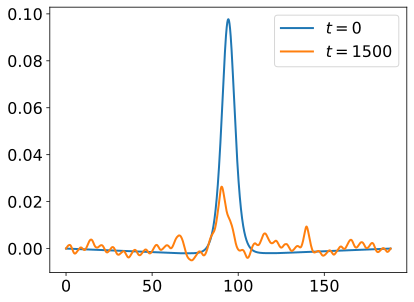

In [23]:
plt.plot(x, phi1[:, 0], label=r"$t=0$")
plt.plot(x, phi1[:, -1], label=r"$t=1500$")
plt.legend()
plt.show()

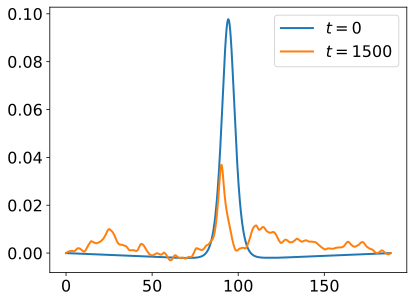

In [24]:
plt.plot(x, phi2[:, 0], label=r"$t=0$")
plt.plot(x, phi2[:, -1], label=r"$t=1500$")
plt.legend()
plt.show()